<a href="https://colab.research.google.com/github/Ainun-Haseeb/Coursera_Machine_learning/blob/main/Copy_of_SVM_Project_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/My Drive/students_grades_placement (1).csv'
df = pd.read_csv(file_path)

In [ ]:
dataset = df
dataset

,Roll_Number,Course_1,Course_2,Course_3,Course_4,Course_5,Course_6,Course_7,Course_8,Course_9,...,Course_36,Course_37,Course_38,Course_39,Course_40,Branch,Six_Month_Internship,CGPA,Placed,Average_CTC
0,1,9.75,8.66,7.99,5.78,5.78,5.29,9.33,8.01,8.54,...,6.52,5.49,8.42,7.20,5.61,4,0,7.25,0,NaN
1,2,6.96,5.91,8.78,7.13,6.04,7.84,5.16,9.21,7.25,...,8.26,9.57,9.25,7.25,5.48,6,0,7.58,0,NaN
2,3,8.65,8.19,9.44,7.36,5.60,8.57,8.80,7.81,8.85,...,9.48,6.59,5.55,6.14,7.14,5,1,7.53,1,7.16
3,4,7.09,6.11,5.60,6.69,9.71,6.62,7.59,8.52,6.82,...,9.18,6.60,5.93,5.20,7.95,3,1,7.29,1,6.58
4,5,6.74,5.48,9.70,6.99,7.59,9.19,8.38,8.68,6.05,...,6.42,6.53,7.43,7.24,9.97,3,0,8.04,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,8.15,5.32,8.30,8.98,5.32,9.24,5.62,5.88,9.18,...,8.72,6.86,6.63,9.61,9.44,5,1,7.51,1,25.22
1996,1997,7.82,8.69,5.67,9.65,9.86,6.77,9.73,8.98,9.71,...,9.23,6.32,8.87,9.14,6.63,2,0,7.70,1,11.10
1997,1998,9.02,6.56,6.36,5.38,7.93,7.66,8.31,7.34,6.03,...,9.25,5.57,8.02,6.03,8.32,2,1,7.42,1,11.94
1998,1999,7.21,5.07,9.76,5.64,6.48,8.65,5.03,7.71,5.79,...,7.82,7.07,7.62,9.89,9.47,4,1,7.62,1,8.91


In [ ]:
Features = [f'Course_{i}' for i in range(1, 41)] + ['Branch', 'Six_Month_Internship', 'CGPA', 'Average_CTC']

In [ ]:
X = df[Features]
y = df['Placed']

In [ ]:
from sklearn.impute import SimpleImputer # Import SimpleImputer

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Impute missing values
# Using the mean strategy to replace NaNs
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Standardize features
scaler = StandardScaler()
# Fit on imputed training data and transform both imputed training and test data
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Overwrite X_train_imputed and X_test_imputed with the scaled versions
# to ensure subsequent cells use the fully preprocessed data.
X_train_imputed = X_train_scaled
X_test_imputed = X_test_scaled

In [ ]:
# Create and train SVM models
models = {
    'Linear SVM': SVC(kernel='linear', C=1.0),
    'RBF SVM': SVC(kernel='rbf', gamma='scale', C=5)
}
for model in models.values():
    # Fit the model using the imputed training data
    model.fit(X_train_imputed, y_train)

In [ ]:
# Create grid for decision boundary visualization
x_min, x_max = X_train_imputed[:, 0].min()-1, X_train_imputed[:, 0].max()+1
y_min, y_max = X_train_imputed[:, 1].min()-1, X_train_imputed[:, 1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

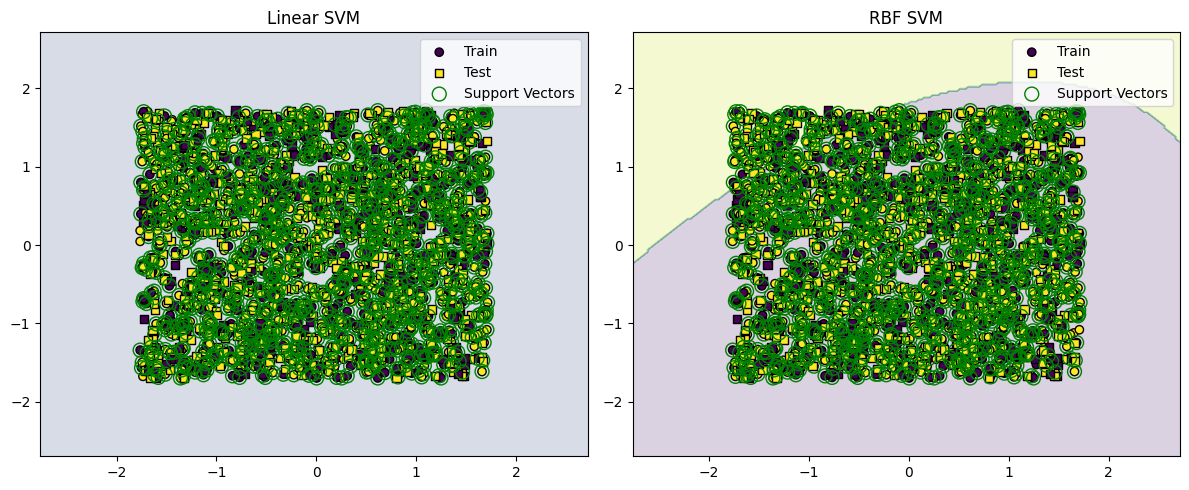

In [ ]:
# Plot results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Calculate the mean of features from the 3rd feature onwards for creating the full grid
mean_other_features = X_train_imputed[:, 2:].mean(axis=0)

for ax, (name, model) in zip(axes, models.items()):
    # Create a full 44-feature grid for prediction
    # We use the xx and yy (first two features) and append the mean of the rest
    grid_2d = np.c_[xx.ravel(), yy.ravel()]
    expanded_mean_features = np.tile(mean_other_features, (xx.ravel().shape[0], 1))
    grid_full = np.c_[grid_2d, expanded_mean_features]

    # Plot decision boundary
    Z = model.predict(grid_full).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2)

    # Plot data points using the correctly scaled and imputed data (first two features for visualization)
    ax.scatter(X_train_imputed[:, 0], X_train_imputed[:, 1], c=y_train, marker='o', label='Train', edgecolors='k')
    ax.scatter(X_test_imputed[:, 0], X_test_imputed[:, 1], c=y_test, marker='s', label='Test', edgecolors='k', facecolors='none')

    # Highlight support vectors - support_vectors_ are also 44-dimensional, so select the first two features
    # Note: To plot support vectors correctly, you would need to project them onto the 2D plane as well.
    # For simplicity and to resolve the error, we'll keep this commented out for now if not directly applicable to 2D projection.
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                s=100, facecolors='none', edgecolors='green', label='Support Vectors')

    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
y_pred_linear = models['Linear SVM'].predict(X_test_imputed)
y_pred_rbf = models['RBF SVM'].predict(X_test_imputed)

In [ ]:

# Calculate metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
linear_metrics = [accuracy_score(y_test, y_pred_linear),
                  precision_score(y_test, y_pred_linear, average='weighted', zero_division=0),
                  recall_score(y_test, y_pred_linear, average='weighted', zero_division=0),
                  f1_score(y_test, y_pred_linear, average='weighted', zero_division=0)]

rbf_metrics = [accuracy_score(y_test, y_pred_rbf),
               precision_score(y_test, y_pred_rbf, average='weighted', zero_division=0),
               recall_score(y_test, y_pred_rbf, average='weighted', zero_division=0),
               f1_score(y_test, y_pred_rbf, average='weighted', zero_division=0)]

In [ ]:
# Display results
print("Kernel\t\tAccuracy\tPrecision\tRecall\t\tF1-Score")
print("-"*60)
print(f"Linear\t\t{linear_metrics[0]:.4f}\t\t{linear_metrics[1]:.4f}\t\t{linear_metrics[2]:.4f}\t\t{linear_metrics[3]:.4f}")
print(f"RBF\t\t{rbf_metrics[0]:.4f}\t\t{rbf_metrics[1]:.4f}\t\t{rbf_metrics[2]:.4f}\t\t{rbf_metrics[3]:.4f}")

# Best kernel
print(f"\nBest Kernel: {'RBF' if sum(rbf_metrics)/4 > sum(linear_metrics)/4 else 'Linear'}")

Kernel		Accuracy	Precision	Recall		F1-Score
------------------------------------------------------------
Linear		0.6667		0.4444		0.6667		0.5333
RBF		0.7117		0.6973		0.7117		0.6980

Best Kernel: RBF


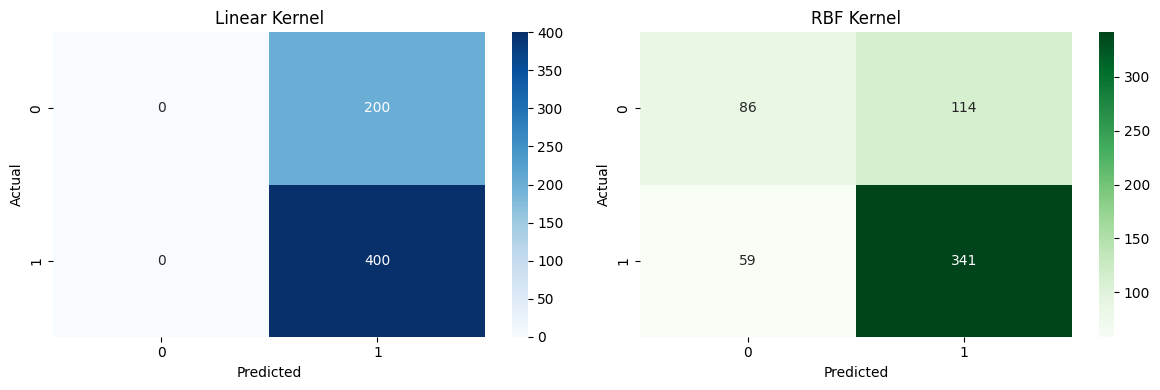

Linear Kernel CM:
 [[  0 200]
 [  0 400]]

RBF Kernel CM:
 [[ 86 114]
 [ 59 341]]


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate confusion matrices
cm_linear = confusion_matrix(y_test, y_pred_linear)
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

# Display both matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Linear Kernel')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('RBF Kernel')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Print numeric values
print("Linear Kernel CM:\n", cm_linear)
print("\nRBF Kernel CM:\n", cm_rbf)